<a href="https://colab.research.google.com/github/EktaSinghES/Machine_Learning_Lab-2547221/blob/LAB9/Lab_9_SVM_PCA_LDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 9: Support Vector Machine and Principal Component Analysis

## Aim

To implement Support Vector Machine (SVM) for classification and Principal Component Analysis (PCA) for dimensionality reduction, and analyse their effectiveness using real-world datasets.

## Objectives

1. Implement and evaluate an SVM classifier using different kernel functions.
2. Compare SVM models using accuracy, precision, recall, F1 score, and a confusion matrix.
3. Apply PCA to reduce a high-dimensional dataset from 13 features to two principal components.
4. Analyse individual and cumulative explained variance.
5. Visualize the PCA-transformed feature space.
6. Understand the different roles of supervised learning (SVM and LDA) and unsupervised learning (PCA).
7. Apply LDA as an extra-credit supervised dimensionality-reduction technique and compare it with PCA.

## Datasets

- **Part A:** [UCI Breast Cancer Wisconsin (Diagnostic)](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic) — 569 instances, 30 continuous predictors, two diagnostic classes, and no missing values.
- **Part B:** [UCI Wine](https://archive.ics.uci.edu/dataset/109/wine) — 178 instances, 13 chemical measurements, three cultivar classes, and no missing values.

The equivalent copies bundled with scikit-learn are used so the notebook runs reproducibly without manual downloads.

## Software and experimental settings

- Python 3, NumPy, pandas, Matplotlib, and scikit-learn
- Random state: `42`
- SVM split: stratified 80% training and 20% testing
- Hyperparameter selection: five-fold stratified cross-validation on the training set only
- Cross-validation metric: F1 score
- Scaling and SVM are kept in one pipeline to prevent information leakage


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.datasets import load_breast_cancer, load_wine
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay,
                             silhouette_score, roc_curve, auc,
                             precision_recall_curve, average_precision_score)
from sklearn.model_selection import (GridSearchCV, StratifiedKFold, train_test_split,
                                     learning_curve, cross_val_score)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

RANDOM_STATE = 42
pd.set_option('display.precision', 4)


## Part A — Support Vector Machine (SVM)

### Aim

To implement an SVM classifier for a binary classification problem, tune a linear SVM, compare kernel functions, and evaluate the final model.

### Theory

SVM is a supervised learning method that constructs a decision boundary with the largest possible margin between classes. The observations closest to the boundary are the **support vectors**. A large margin generally improves generalization.

The regularization parameter `C` controls the trade-off between margin width and classification errors:

- Small `C`: stronger regularization, wider margin, and more tolerance of training errors.
- Large `C`: weaker regularization, narrower margin, and a stronger attempt to classify every training sample correctly.

Kernel functions allow SVM to represent different decision boundaries:

- **Linear:** a straight hyperplane; efficient and interpretable.
- **RBF:** a nonlinear boundary based on local similarity.
- **Polynomial:** polynomial feature interactions.
- **Sigmoid:** a neural-network-like nonlinear transformation.

### Dataset and preprocessing

The Breast Cancer Wisconsin (Diagnostic) dataset contains 569 samples described by 30 real-valued measurements obtained from digitized images of breast-mass cell nuclei. The target classes are malignant and benign. The dataset contains no missing values.

Preprocessing procedure:

1. Load the feature matrix and target labels.
2. Confirm dimensions, class distribution, and missing values.
3. Split the observations into 80% training and 20% testing sets using stratification.
4. Standardize every feature because SVM distances and margins are scale-sensitive.
5. Learn the scaler only from the relevant training fold by placing it inside a pipeline.


In [ ]:
cancer = load_breast_cancer(as_frame=True)
X_cancer, y_cancer = cancer.data, cancer.target

print('Shape:', X_cancer.shape)
print('Missing values:', int(X_cancer.isna().sum().sum()))
print('Target coding:', dict(enumerate(cancer.target_names)))
display(X_cancer.head())
display(y_cancer.value_counts().rename(index=dict(enumerate(cancer.target_names))))

X_train, X_test, y_train, y_test = train_test_split(
    X_cancer, y_cancer, test_size=0.20, random_state=RANDOM_STATE, stratify=y_cancer
)
print(f'Train: {X_train.shape}; test: {X_test.shape}')

### Linear SVM and hyperparameter tuning

The linear SVM is tuned over:

`C ∈ {0.001, 0.01, 0.1, 1, 10, 100}`

Five-fold stratified cross-validation is performed only on the training portion. F1 score is used for model selection because it balances precision and recall. Under scikit-learn's default target encoding for this dataset, **benign is class 1 and is therefore the positive class** for the reported binary precision, recall, and F1 score.


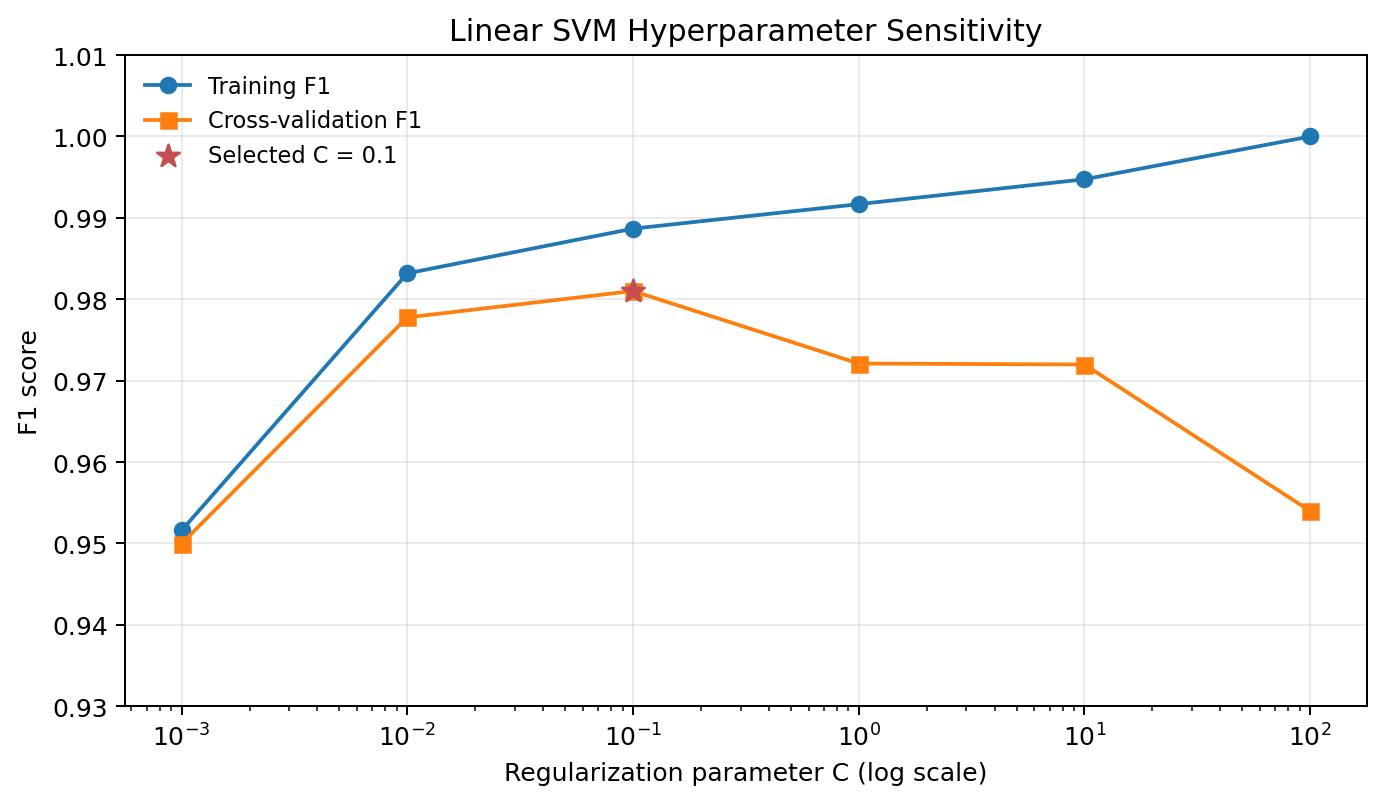

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
linear_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='linear'))
])

linear_search = GridSearchCV(
    linear_pipeline,
    {'svm__C': [0.001, 0.01, 0.1, 1, 10, 100]},
    scoring='f1', cv=cv, n_jobs=1, return_train_score=True
)
linear_search.fit(X_train, y_train)

tuning_results = pd.DataFrame(linear_search.cv_results_)[
    ['param_svm__C', 'mean_train_score', 'mean_test_score', 'std_test_score']
].rename(columns={'param_svm__C': 'C', 'mean_train_score': 'mean_train_f1',
                  'mean_test_score': 'mean_cv_f1', 'std_test_score': 'std_cv_f1'})
display(tuning_results)
print('Best parameters:', linear_search.best_params_)
print(f'Best mean CV F1: {linear_search.best_score_:.4f}')

# Visualize underfitting/overfitting as C changes.
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.semilogx(tuning_results['C'], tuning_results['mean_train_f1'], marker='o', label='Training F1')
ax.semilogx(tuning_results['C'], tuning_results['mean_cv_f1'], marker='s', label='Cross-validation F1')
ax.scatter([linear_search.best_params_['svm__C']], [linear_search.best_score_],
           marker='*', s=140, color='crimson', zorder=5,
           label=f"Selected C = {linear_search.best_params_['svm__C']}")
ax.set(xlabel='Regularization parameter C (log scale)', ylabel='F1 score',
       title='Linear SVM Hyperparameter Sensitivity', ylim=(0.93, 1.01))
ax.grid(alpha=0.25); ax.legend(frameon=False); plt.tight_layout(); plt.show()


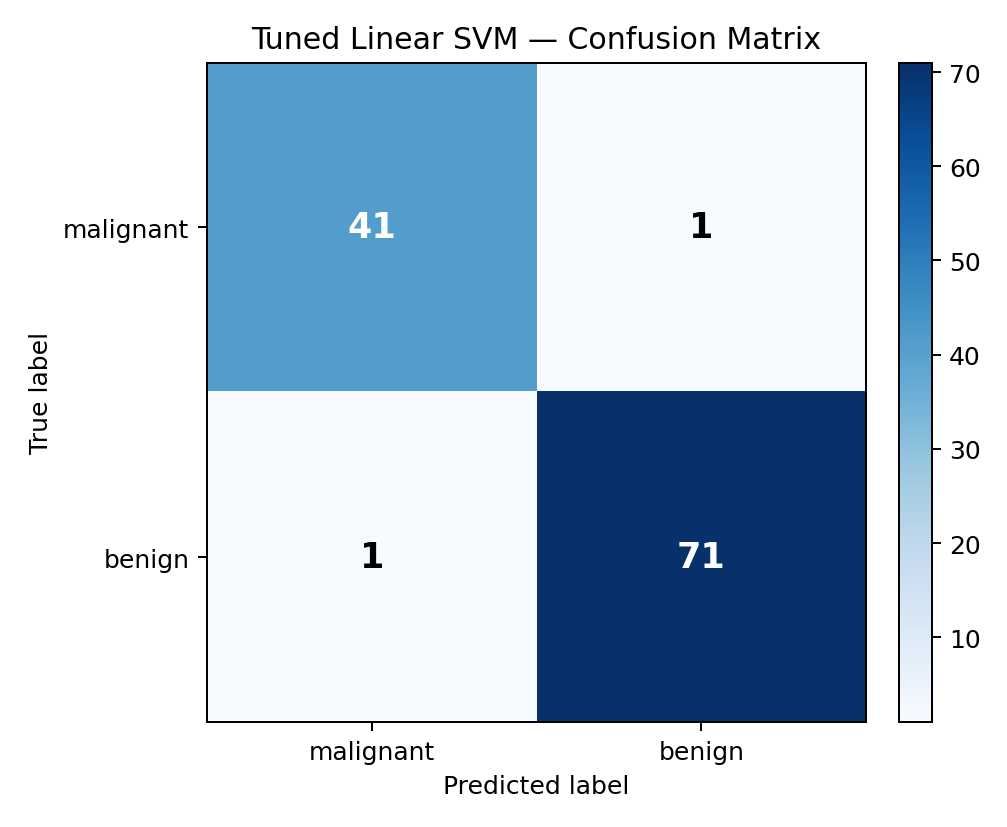

In [ ]:
y_pred = linear_search.predict(X_test)
linear_metrics = pd.Series({
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1 score': f1_score(y_test, y_pred)
}, name='Tuned linear SVM')
display(linear_metrics.to_frame())

cm = confusion_matrix(y_test, y_pred)
display(pd.DataFrame(cm,
                     index=[f'Actual {x}' for x in cancer.target_names],
                     columns=[f'Predicted {x}' for x in cancer.target_names]))
ConfusionMatrixDisplay(cm, display_labels=cancer.target_names).plot(cmap='Blues')
plt.title('Tuned Linear SVM — Confusion Matrix')
plt.tight_layout()
plt.show()

### Linear SVM results

Five-fold cross-validation selected **`C = 0.1`**, with mean validation F1 = **0.9810**. The reduction in validation performance at very large `C` values indicates that weaker regularization begins to overfit the training folds.

| Metric | Test score |
|---|---:|
| Accuracy | 0.9825 |
| Precision | 0.9861 |
| Recall | 0.9861 |
| F1 score | 0.9861 |

The confusion matrix uses actual classes as rows and predicted classes as columns:

|  | Predicted malignant | Predicted benign |
|---|---:|---:|
| Actual malignant | 41 | 1 |
| Actual benign | 1 | 71 |


### Observations

- The model correctly classified 112 of the 114 test observations.
- One malignant case was predicted as benign and one benign case was predicted as malignant.
- Precision and recall are equal and high, indicating balanced performance for the benign-positive coding.
- `C = 0.1` gives a regularized, relatively wide-margin solution and generalizes better in cross-validation than the less-regularized alternatives.
- Because the held-out set contains only 114 observations, differences of one or two cases should not be overinterpreted.
- In an actual medical application, malignant-class sensitivity, specificity, probability calibration, external validation, fairness, and clinical oversight would also be required. This experiment is an educational evaluation, not a clinical validation.


### Hyperparameter-tuning visualization


Training F1 continues to rise as `C` becomes very large, but validation F1 peaks at `C = 0.1` and then falls. This widening gap is evidence that weak regularization increases overfitting.


### Comparison of SVM kernels

To satisfy the objective of comparing kernel functions, linear, RBF, polynomial, and sigmoid SVMs are tuned using the same training folds. Each search includes standardization inside the pipeline. The test set remains untouched until the best settings for each kernel have been selected by cross-validation.


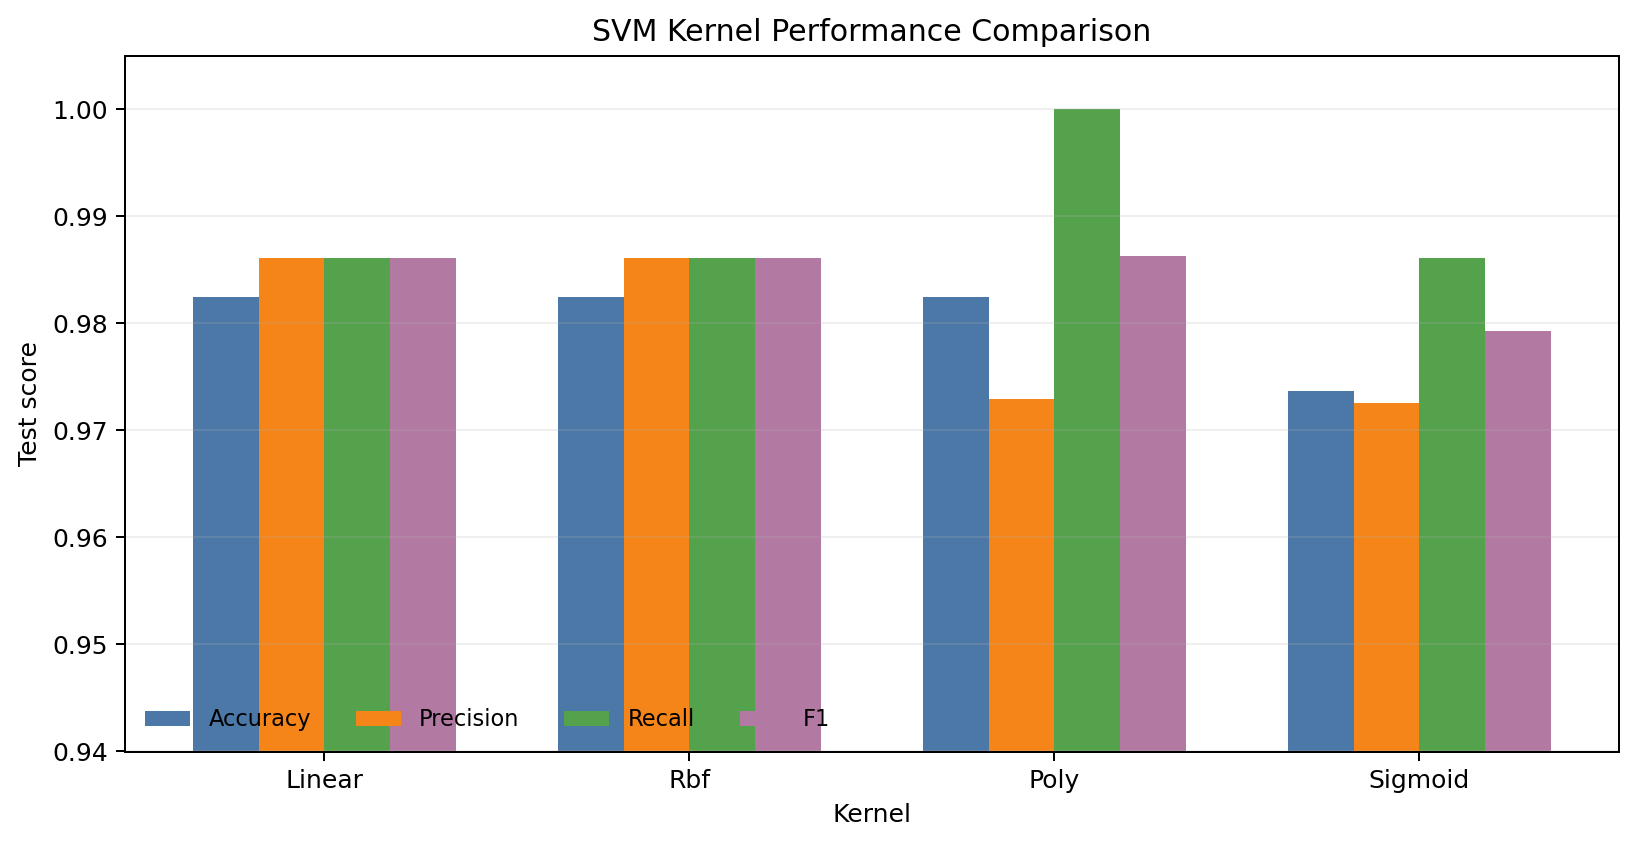

In [ ]:
kernel_grids = {
    'linear': {'svm__kernel': ['linear'], 'svm__C': [0.01, 0.1, 1, 10]},
    'rbf': {'svm__kernel': ['rbf'], 'svm__C': [0.1, 1, 10, 100],
            'svm__gamma': ['scale', 0.001, 0.01, 0.1]},
    'poly': {'svm__kernel': ['poly'], 'svm__C': [0.1, 1, 10],
             'svm__degree': [2, 3], 'svm__gamma': ['scale', 0.01, 0.1]},
    'sigmoid': {'svm__kernel': ['sigmoid'], 'svm__C': [0.01, 0.1, 1, 10],
                'svm__gamma': ['scale', 0.001, 0.01, 0.1]}
}

kernel_rows = []
for kernel, grid in kernel_grids.items():
    model = Pipeline([('scaler', StandardScaler()), ('svm', SVC())])
    search = GridSearchCV(model, grid, scoring='f1', cv=cv, n_jobs=1)
    search.fit(X_train, y_train)
    pred = search.predict(X_test)
    kernel_rows.append({
        'kernel': kernel, 'best_parameters': search.best_params_,
        'cv_f1': search.best_score_,
        'test_accuracy': accuracy_score(y_test, pred),
        'test_precision': precision_score(y_test, pred),
        'test_recall': recall_score(y_test, pred),
        'test_f1': f1_score(y_test, pred)
    })
kernel_comparison = pd.DataFrame(kernel_rows).set_index('kernel')
display(kernel_comparison)

# Compare all requested test metrics visually.
metric_columns = ['test_accuracy', 'test_precision', 'test_recall', 'test_f1']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1']
x_positions = np.arange(len(kernel_comparison))
bar_width = 0.18
fig, ax = plt.subplots(figsize=(9.5, 4.8))
for index, (column, label) in enumerate(zip(metric_columns, metric_labels)):
    ax.bar(x_positions + (index - 1.5) * bar_width,
           kernel_comparison[column], bar_width, label=label)
ax.set_xticks(x_positions, [name.title() for name in kernel_comparison.index])
ax.set(xlabel='Kernel', ylabel='Test score', title='SVM Kernel Performance Comparison',
       ylim=(0.94, 1.005))
ax.grid(axis='y', alpha=0.2); ax.legend(ncol=4, frameon=False)
plt.tight_layout(); plt.show()


### Kernel comparison results

| Kernel | Best settings | CV F1 | Test accuracy | Test precision | Test recall | Test F1 |
|---|---|---:|---:|---:|---:|---:|
| Linear | `C=0.1` | 0.9810 | 0.9825 | 0.9861 | 0.9861 | 0.9861 |
| RBF | `C=10, gamma=0.01` | 0.9810 | 0.9825 | 0.9861 | 0.9861 | 0.9861 |
| Polynomial | `C=1, degree=3, gamma=0.1` | 0.9712 | 0.9825 | 0.9730 | 1.0000 | 0.9863 |
| Sigmoid | `C=1, gamma=0.01` | 0.9778 | 0.9737 | 0.9726 | 0.9861 | 0.9793 |

### Kernel observations

- Linear and RBF produce identical held-out predictions and nearly identical cross-validation F1 scores.
- The polynomial model has perfect benign-class recall but slightly lower precision; its tiny F1 advantage on this particular test set corresponds to a different trade-off involving only one case.
- The sigmoid kernel performs slightly worse than the other kernels.
- The linear model has the marginally highest cross-validation F1, needs fewer tuning choices, is computationally simpler, and is easier to interpret. It is therefore a sensible final model.
- Similar linear and RBF results suggest that standardized features are already close to linearly separable in the relevant feature space.



The compressed vertical scale makes the small differences visible: the sigmoid model is consistently lower, while the polynomial model exchanges a little precision for perfect benign-class recall.


## Part B — Principal Component Analysis (PCA)

### Aim

To standardize the UCI Wine dataset, reduce its 13 original features to two principal components, analyse explained variance, determine the number of components required for at least 95% variance, and visualize the transformed data.

### Theory

PCA is an **unsupervised linear transformation**. It creates new orthogonal variables called principal components:

- PC1 is the direction containing the maximum possible variance.
- PC2 contains the maximum remaining variance subject to being orthogonal to PC1.
- Later components continue in the same way.

The explained variance ratio of a component is the proportion of total standardized variance represented by that component. The cumulative explained variance is the running sum of these ratios.

PCA does not use class labels. Consequently, directions with high overall variance are not guaranteed to be the directions that best separate classes.

### Dataset and preprocessing

The Wine dataset contains 178 observations from three Italian wine cultivars. Each observation has 13 chemical measurements. Because features such as proline, magnesium, alcohol, and color intensity use different scales and units, every feature is standardized to zero mean and unit variance before PCA.

### Procedure

1. Load the Wine feature matrix and labels.
2. Check dimensions and missing values.
3. Standardize all 13 features.
4. Fit PCA using all components to analyse the variance curve.
5. Find the smallest component count whose cumulative explained variance is at least 95%.
6. Fit a separate two-component PCA for visualization.
7. Inspect the component loadings to interpret PC1 and PC2.


In [ ]:
wine = load_wine(as_frame=True)
X_wine, y_wine = wine.data, wine.target
print('Shape:', X_wine.shape)
print('Missing values:', int(X_wine.isna().sum().sum()))
display(X_wine.head())

scaler = StandardScaler()
X_wine_scaled = scaler.fit_transform(X_wine)
print('Largest absolute standardized mean:', np.abs(X_wine_scaled.mean(axis=0)).max())
print('Standardized feature standard deviations:', X_wine_scaled.std(axis=0).round(4))

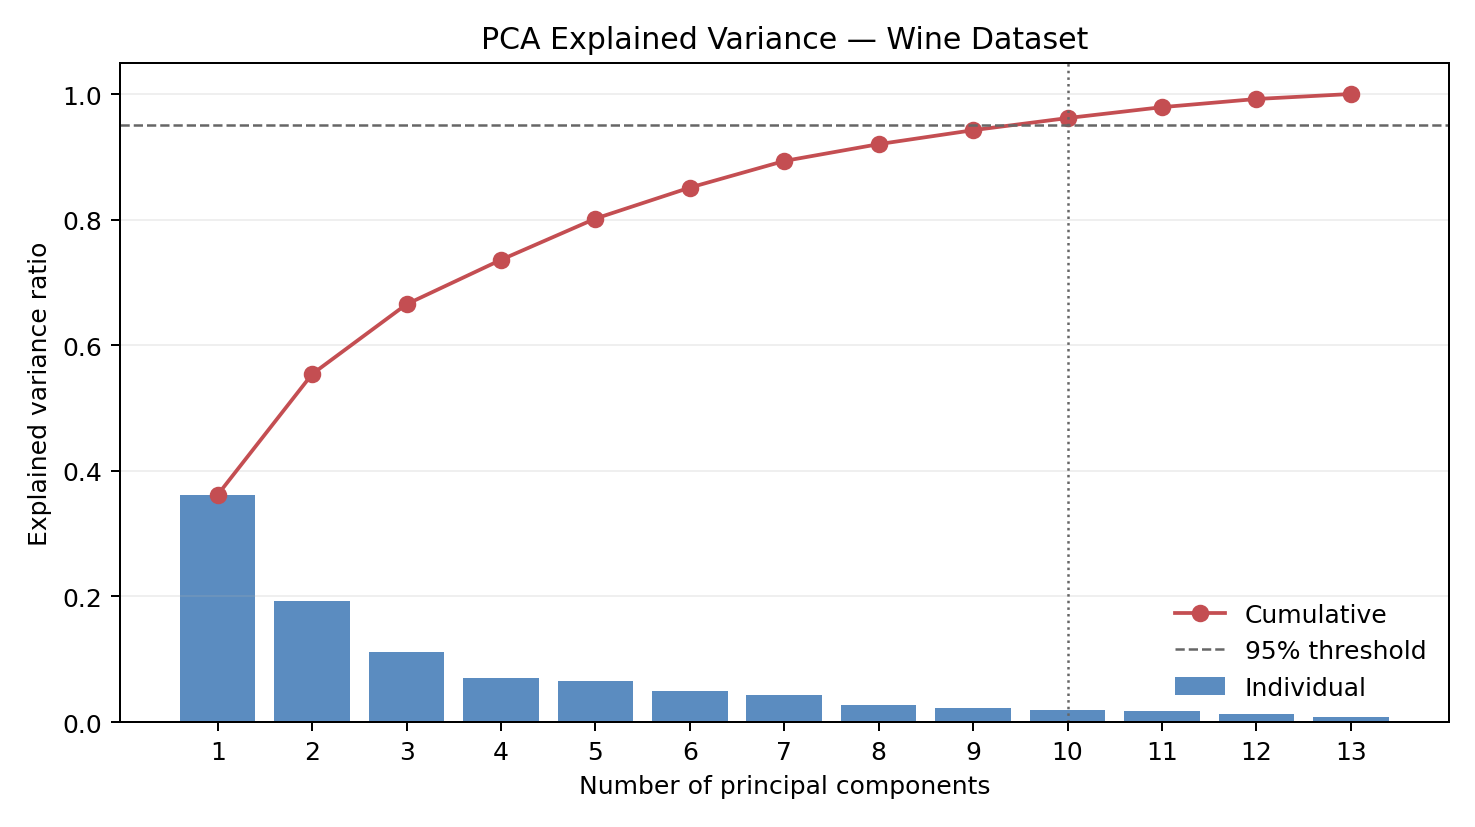

In [ ]:
# Full PCA is used to analyse the complete variance curve.
pca_full = PCA()
pca_full.fit(X_wine_scaled)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

variance_table = pd.DataFrame({
    'PC': np.arange(1, X_wine.shape[1] + 1),
    'Explained variance ratio': pca_full.explained_variance_ratio_,
    'Cumulative variance': cumulative_variance
})
display(variance_table)
print(f'Minimum components for at least 95% variance: {n_components_95}')
print(f'Variance retained: {cumulative_variance[n_components_95 - 1]:.4%}')

fig, ax = plt.subplots(figsize=(9, 5))
positions = np.arange(1, X_wine.shape[1] + 1)
ax.bar(positions, pca_full.explained_variance_ratio_, label='Individual')
ax.plot(positions, cumulative_variance, marker='o', color='crimson', label='Cumulative')
ax.axhline(0.95, color='gray', linestyle='--', label='95% threshold')
ax.axvline(n_components_95, color='gray', linestyle=':')
ax.set(xlabel='Number of principal components', ylabel='Explained variance ratio',
       title='PCA Explained Variance — Wine Dataset', xticks=positions, ylim=(0, 1.05))
ax.legend(); ax.grid(axis='y', alpha=0.2); plt.tight_layout(); plt.show()

In [ ]:
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_wine_scaled)
print('PC1 and PC2 explained variance ratios:', pca_2d.explained_variance_ratio_)
print(f'Total variance retained by 2 PCs: {pca_2d.explained_variance_ratio_.sum():.4%}')

pca_frame = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_frame['class'] = y_wine.to_numpy()
display(pca_frame.head())

fig, ax = plt.subplots(figsize=(8, 6))
for class_id, class_name in enumerate(wine.target_names):
    mask = y_wine.to_numpy() == class_id
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], label=class_name, alpha=0.75)
ax.set(xlabel='Principal Component 1', ylabel='Principal Component 2',
       title='Wine Dataset Projected onto Two Principal Components')
ax.legend(); ax.grid(alpha=0.2); plt.tight_layout(); plt.show()

### PCA results

| Component | Explained variance ratio | Cumulative variance |
|---|---:|---:|
| PC1 | 0.3620 | 0.3620 |
| PC2 | 0.1921 | 0.5541 |
| PC3 | 0.1112 | 0.6653 |
| PC4 | 0.0707 | 0.7360 |
| PC5 | 0.0656 | 0.8016 |
| PC6 | 0.0494 | 0.8510 |
| PC7 | 0.0424 | 0.8934 |
| PC8 | 0.0268 | 0.9202 |
| PC9 | 0.0222 | 0.9424 |
| PC10 | 0.0193 | 0.9617 |
| PC11 | 0.0174 | 0.9791 |
| PC12 | 0.0130 | 0.9920 |
| PC13 | 0.0080 | 1.0000 |

The first two components retain **55.41%** of the total standardized variance. They make a useful two-dimensional visualization but discard **44.59%**, so the 2D representation is not a near-lossless replacement for the original data.

Nine components retain 94.24%, which is below the requested threshold. The minimum number required for at least 95% is therefore **10 components**, retaining **96.17%**.


### Interpretation of PC1 and PC2

The strongest PC1 loadings by absolute magnitude are flavanoids (+0.423), total phenols (+0.395), OD280/OD315 of diluted wines (+0.376), proanthocyanins (+0.313), and nonflavanoid phenols (−0.299). PC1 can therefore be interpreted mainly as a **phenolic-composition or antioxidant axis**.

The strongest PC2 loadings are color intensity (+0.530), alcohol (+0.484), proline (+0.365), ash (+0.316), and magnesium (+0.300). PC2 can be interpreted mainly as an **alcohol, color, and concentration/mineral axis**.

The sign of a PCA component is arbitrary: multiplying a component and all its loadings by −1 produces an equivalent solution. Interpretation should therefore emphasize the magnitude and grouping of loadings rather than the sign alone.

### Original versus transformed dataset

| Aspect | Original standardized data | PCA with 2 components | PCA retaining at least 95% |
|---|---|---|---|
| Number of features | 13 | 2 | 10 |
| Variance retained | 100% | 55.41% | 96.17% |
| Visualization | Cannot be displayed directly in one plot | Direct 2D scatter plot | Still high-dimensional |
| Feature-dependent computation | Baseline | About 84.6% fewer columns | About 23.1% fewer columns |
| Interpretability | Original chemical measurements | Abstract linear combinations | Abstract linear combinations |

The two-component version provides much greater computational reduction and direct visualization, but at a substantial information cost. Ten components preserve most of the variance but offer only modest dimensionality reduction.


In [ ]:
loadings = pd.DataFrame(
    pca_full.components_[:2].T, index=X_wine.columns, columns=['PC1', 'PC2']
)
print('Top PC1 loadings by absolute magnitude:')
display(loadings['PC1'].reindex(loadings['PC1'].abs().sort_values(ascending=False).index).head())
print('Top PC2 loadings by absolute magnitude:')
display(loadings['PC2'].reindex(loadings['PC2'].abs().sort_values(ascending=False).index).head())

### Advantages of PCA

- Reduces storage and feature-dependent computation.
- Removes exact linear correlation between transformed features.
- Can reduce multicollinearity and suppress some low-variance noise.
- Enables two- and three-dimensional exploratory visualization.
- Is deterministic, efficient, and widely available.

### Limitations of PCA

- Models linear structure only and may miss nonlinear manifolds.
- Ignores target labels, so maximum variance may not mean maximum class separation.
- Is sensitive to feature scale; standardization is usually essential.
- Can be influenced by outliers.
- Components may be harder to explain than original variables.
- Low-variance directions may still contain useful predictive information.

### Applications of PCA

- Image and signal compression
- Denoising and feature extraction
- Gene-expression and other high-dimensional biological data
- Exploratory visualization
- Preprocessing before clustering or classification
- Reduction of multicollinearity in regression pipelines


## Extra credit — Linear Discriminant Analysis (LDA)

### Aim

To reduce the same Wine dataset to two linear discriminants, visualize the transformed observations, and compare PCA and LDA in terms of dimensionality reduction and class separability.

### Theory

LDA is supervised: it uses the target labels and finds directions that maximize between-class separation relative to within-class scatter. With `K` classes, LDA can create at most `K − 1` discriminants. The Wine dataset has three classes, so at most two discriminants are available.

The Wine features are standardized and then transformed to LD1 and LD2. For this descriptive visualization, the transformation is fitted to the full dataset. If the aim were to estimate predictive generalization, scaling and LDA would instead need to be fitted inside each training fold of cross-validation.


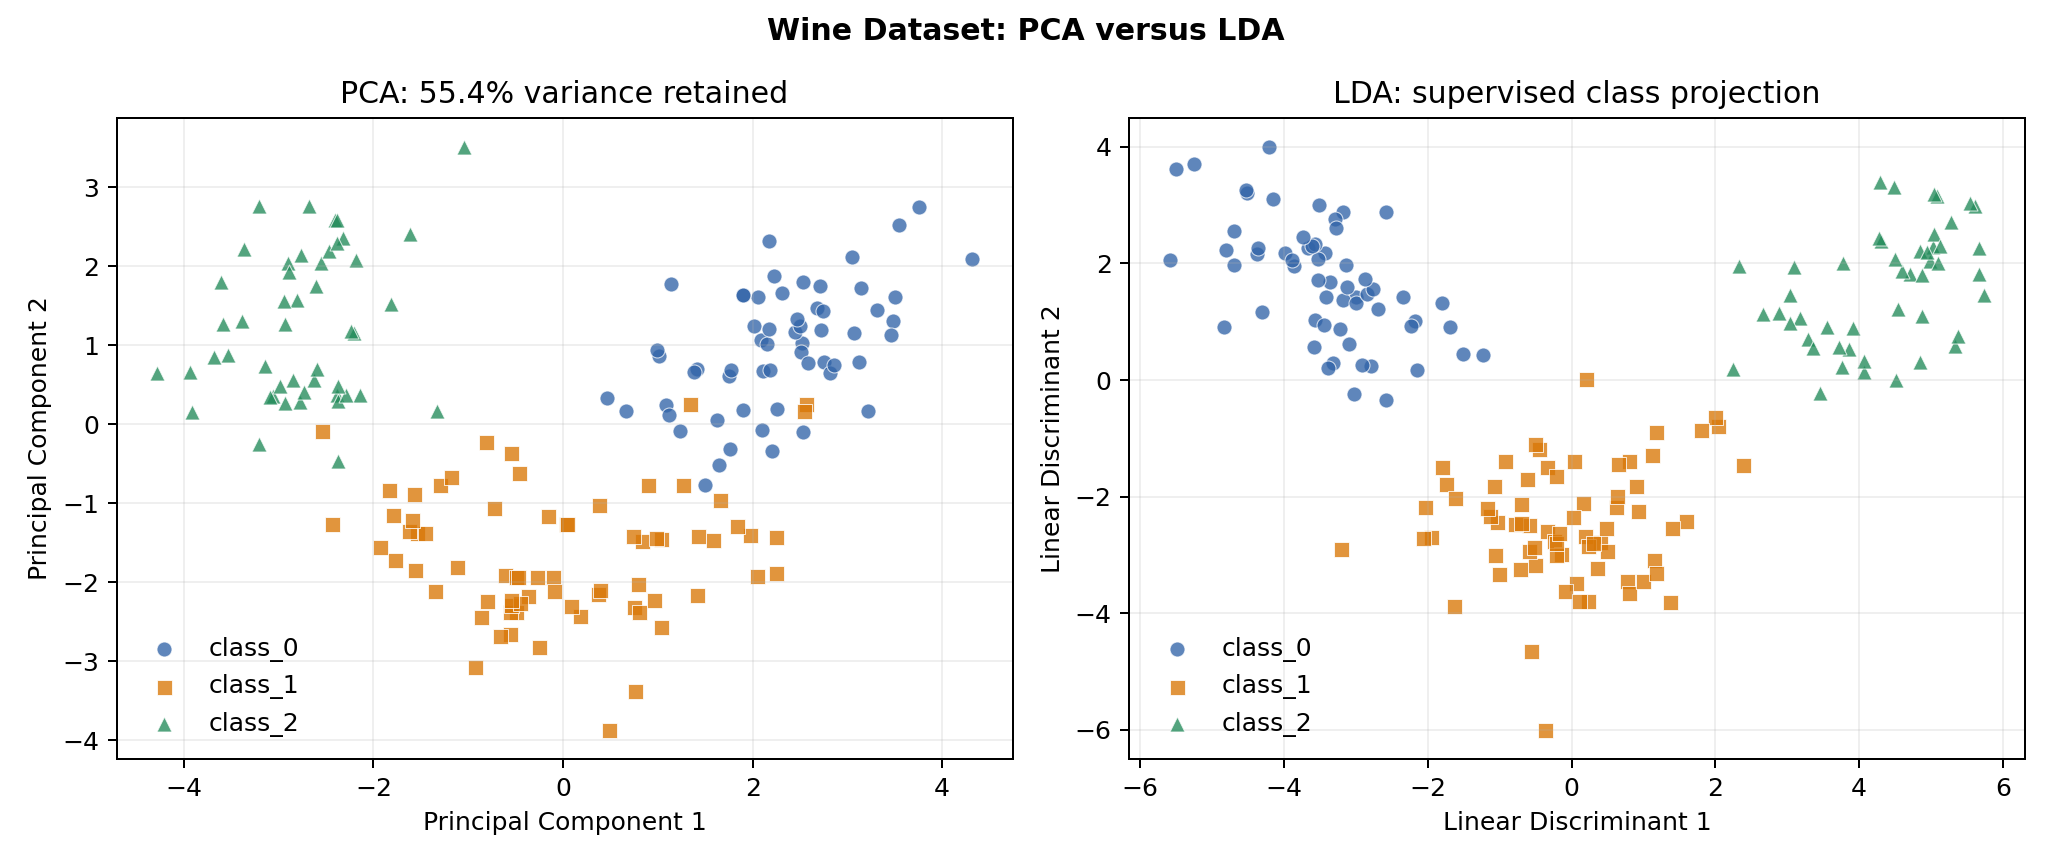

In [ ]:
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_wine_scaled, y_wine)
print('LDA discriminant ratios:', lda.explained_variance_ratio_)
print(f'PCA class-label silhouette: {silhouette_score(X_pca, y_wine):.4f}')
print(f'LDA class-label silhouette: {silhouette_score(X_lda, y_wine):.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for class_id, class_name in enumerate(wine.target_names):
    mask = y_wine.to_numpy() == class_id
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], label=class_name, alpha=0.75)
    axes[1].scatter(X_lda[mask, 0], X_lda[mask, 1], label=class_name, alpha=0.75)
axes[0].set(title='PCA: 55.41% variance retained', xlabel='PC1', ylabel='PC2')
axes[1].set(title='LDA: supervised class projection', xlabel='LD1', ylabel='LD2')
for ax in axes:
    ax.legend(); ax.grid(alpha=0.2)
plt.tight_layout(); plt.show()

### PCA and LDA visualization


### PCA versus LDA

| Property | PCA with 2 components | LDA with 2 discriminants |
|---|---|---|
| Learning type | Unsupervised | Supervised |
| Uses class labels | No | Yes |
| Primary objective | Maximize total variance | Maximize class separation |
| Maximum dimensions here | 13 | 2 (`classes − 1`) |
| Class-label silhouette score | 0.5262 | 0.6632 |

### LDA observations

- The PCA scatter plot already reveals useful class structure, showing that important overall variance is related to cultivar differences.
- Some PCA overlap remains because the projection was not optimized using labels.
- LDA produces tighter and more clearly separated groups.
- The higher LDA silhouette score, 0.6632 versus 0.5262, quantitatively supports the visual improvement in class separation.
- PCA is preferable when labels are unavailable, general variance preservation is the goal, or unsupervised exploration is required.
- LDA is preferable when reliable labels are available and class discrimination is the main purpose.

## Overall conclusion

The standardized and tuned linear SVM classified the breast-cancer test set with **98.25% accuracy** and **98.61% F1**, making only two errors. Its performance matched the tuned RBF model while retaining a simpler decision function.

For the Wine data, PC1 and PC2 retained **55.41%** of the standardized variance. This was enough to reveal substantial class structure in two dimensions, but **10 components** were required to retain at least 95% of the total variance. LDA used class supervision and produced clearer two-dimensional class separation than PCA.

The experiment demonstrates three distinct machine-learning roles:

- **SVM:** supervised learning of a classification boundary.
- **PCA:** unsupervised, variance-preserving feature transformation.
- **LDA:** supervised feature transformation designed for class separation.

## Dataset references

1. Wolberg, W., Mangasarian, O., Street, N., & Street, W. (1993). *Breast Cancer Wisconsin (Diagnostic)*. UCI Machine Learning Repository. DOI: [10.24432/C5DW2B](https://doi.org/10.24432/C5DW2B).
2. Aeberhard, S. & Forina, M. (1992). *Wine*. UCI Machine Learning Repository. DOI: [10.24432/C5PC7J](https://doi.org/10.24432/C5PC7J).


## Self-learning extensions

The following five investigations go beyond the original questions. Each begins with a new learning question, adds a visualization, and interprets what the result means.

### Self-learning component 1 — How does the SVM behave across decision thresholds?

Accuracy, precision, and recall in Part A describe one decision threshold. ROC and precision–recall curves instead evaluate the ranking quality across all possible thresholds. ROC AUC measures discrimination, while average precision summarizes the precision–recall curve. The positive class here remains benign.


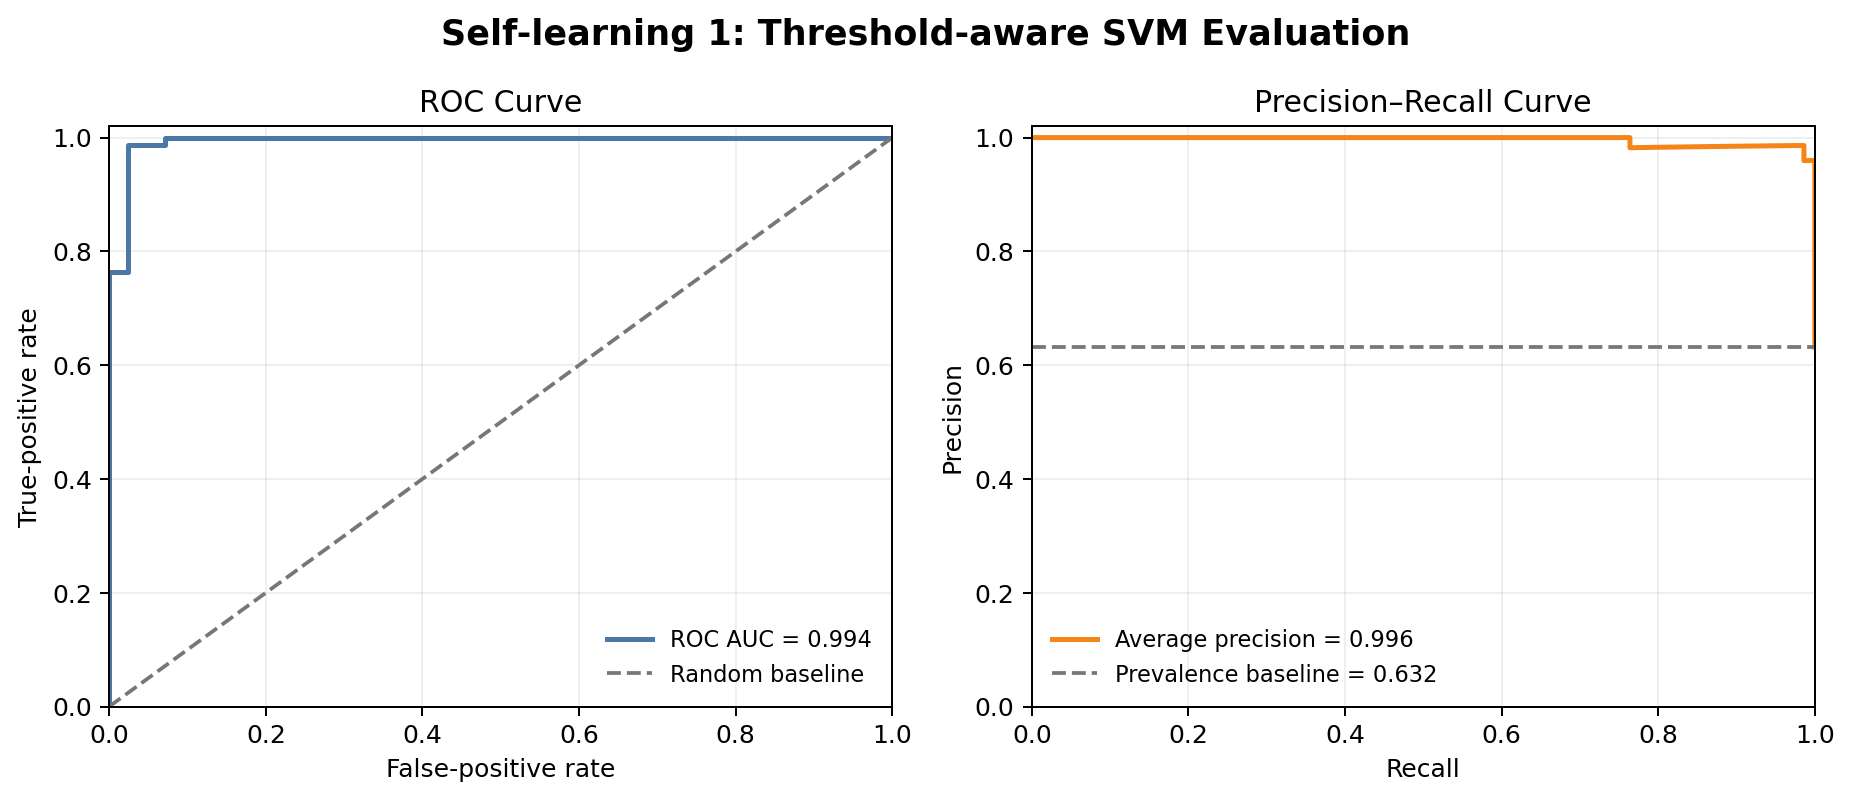

In [ ]:
decision_scores = linear_search.decision_function(X_test)
fpr, tpr, _ = roc_curve(y_test, decision_scores)
roc_auc = auc(fpr, tpr)
pr_precision, pr_recall, _ = precision_recall_curve(y_test, decision_scores)
average_precision = average_precision_score(y_test, decision_scores)
positive_prevalence = y_test.mean()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
axes[0].plot(fpr, tpr, linewidth=2, label=f'ROC AUC = {roc_auc:.3f}')
axes[0].plot([0, 1], [0, 1], '--', color='gray', label='Random baseline')
axes[0].set(xlabel='False-positive rate', ylabel='True-positive rate',
            title='ROC Curve', xlim=(0, 1), ylim=(0, 1.02))
axes[0].legend(frameon=False); axes[0].grid(alpha=0.2)

axes[1].plot(pr_recall, pr_precision, linewidth=2,
             label=f'Average precision = {average_precision:.3f}')
axes[1].axhline(positive_prevalence, linestyle='--', color='gray',
                label=f'Prevalence baseline = {positive_prevalence:.3f}')
axes[1].set(xlabel='Recall', ylabel='Precision', title='Precision–Recall Curve',
            xlim=(0, 1), ylim=(0, 1.02))
axes[1].legend(frameon=False); axes[1].grid(alpha=0.2)
fig.suptitle('Threshold-aware Linear SVM Evaluation', fontweight='bold')
plt.tight_layout(); plt.show()

print(f'ROC AUC: {roc_auc:.4f}')
print(f'Average precision: {average_precision:.4f}')



**Result and interpretation:** ROC AUC is **0.9937** and average precision is **0.9960**, so the SVM ranks the two classes extremely well across thresholds. These curves do not prove that the raw decision scores are calibrated probabilities. For a malignant-positive clinical analysis, the labels or decision scores should be inverted and malignant sensitivity should be emphasized.


### Self-learning component 2 — Would adding more training data probably help?

A learning curve fits the same model using progressively larger training subsets. The distance between training and validation performance helps distinguish high variance from high bias and indicates whether more observations are likely to help.


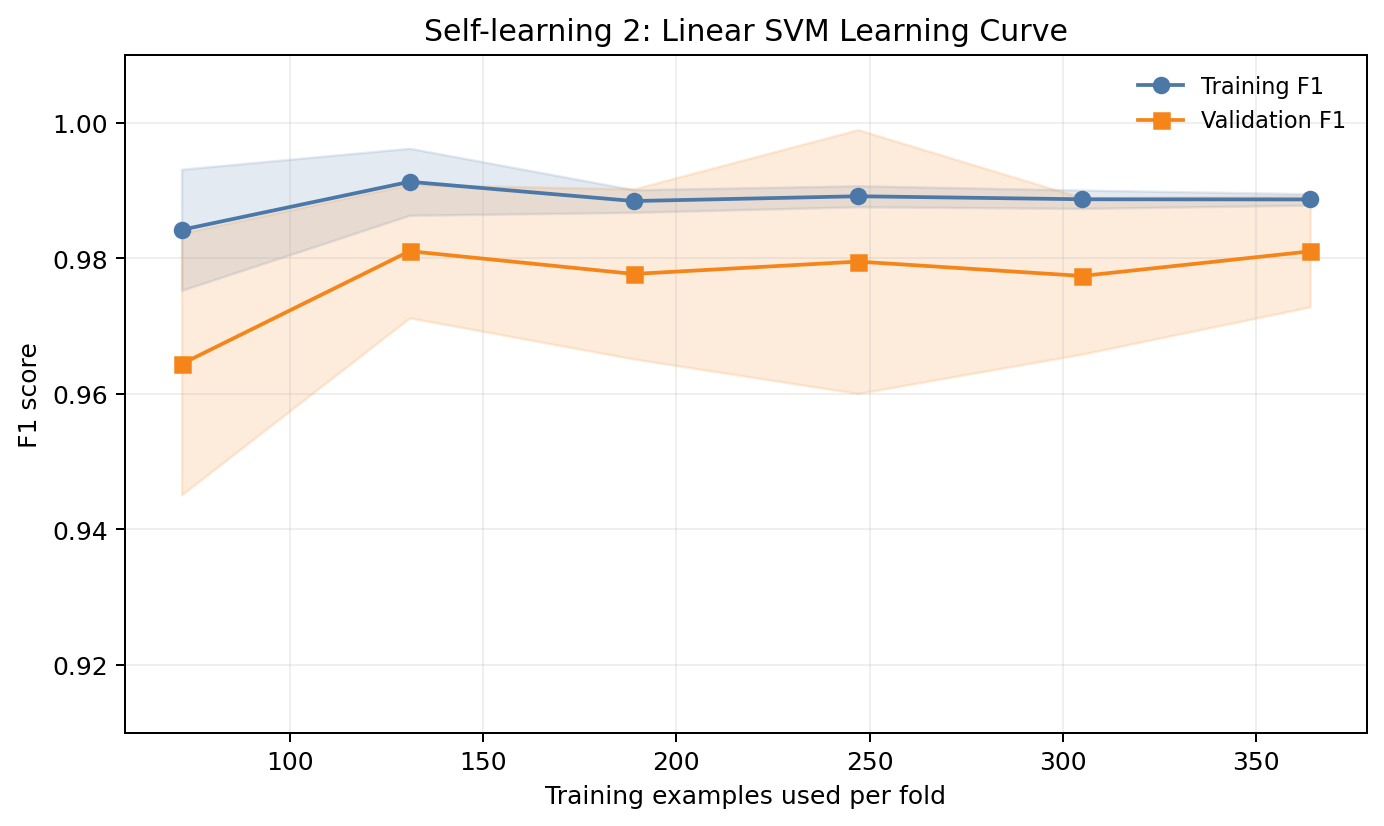

In [ ]:
training_sizes, learning_train, learning_validation = learning_curve(
    linear_search.best_estimator_, X_train, y_train,
    train_sizes=np.linspace(0.2, 1.0, 6), cv=cv, scoring='f1', n_jobs=1
)
train_mean = learning_train.mean(axis=1)
train_std = learning_train.std(axis=1)
validation_mean = learning_validation.mean(axis=1)
validation_std = learning_validation.std(axis=1)

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(training_sizes, train_mean, marker='o', label='Training F1')
ax.fill_between(training_sizes, train_mean-train_std, train_mean+train_std, alpha=0.15)
ax.plot(training_sizes, validation_mean, marker='s', label='Validation F1')
ax.fill_between(training_sizes, validation_mean-validation_std,
                validation_mean+validation_std, alpha=0.15)
ax.set(xlabel='Training examples used per fold', ylabel='F1 score',
       title='Linear SVM Learning Curve', ylim=(0.91, 1.01))
ax.grid(alpha=0.2); ax.legend(frameon=False); plt.tight_layout(); plt.show()
display(pd.DataFrame({'training_examples': training_sizes,
                      'training_f1': train_mean,
                      'validation_f1': validation_mean}))



**Result and interpretation:** Validation F1 rises from approximately **0.9644** with 72 training examples per fold to **0.9810** with 364. At the largest size, training F1 is **0.9887**, leaving a small gap of about 0.008. The model has neither severe bias nor severe variance. More data may provide modest stability improvements, but a dramatic gain is unlikely without new information or features.


### Self-learning component 3 — Which measurements influence the linear SVM boundary most?

Because the final SVM is linear and its inputs are standardized, coefficient magnitudes provide a model-specific measure of influence. A negative coefficient pushes the decision toward malignant (class 0); a positive coefficient pushes it toward benign (class 1). This is an association with the fitted boundary, not a causal explanation.


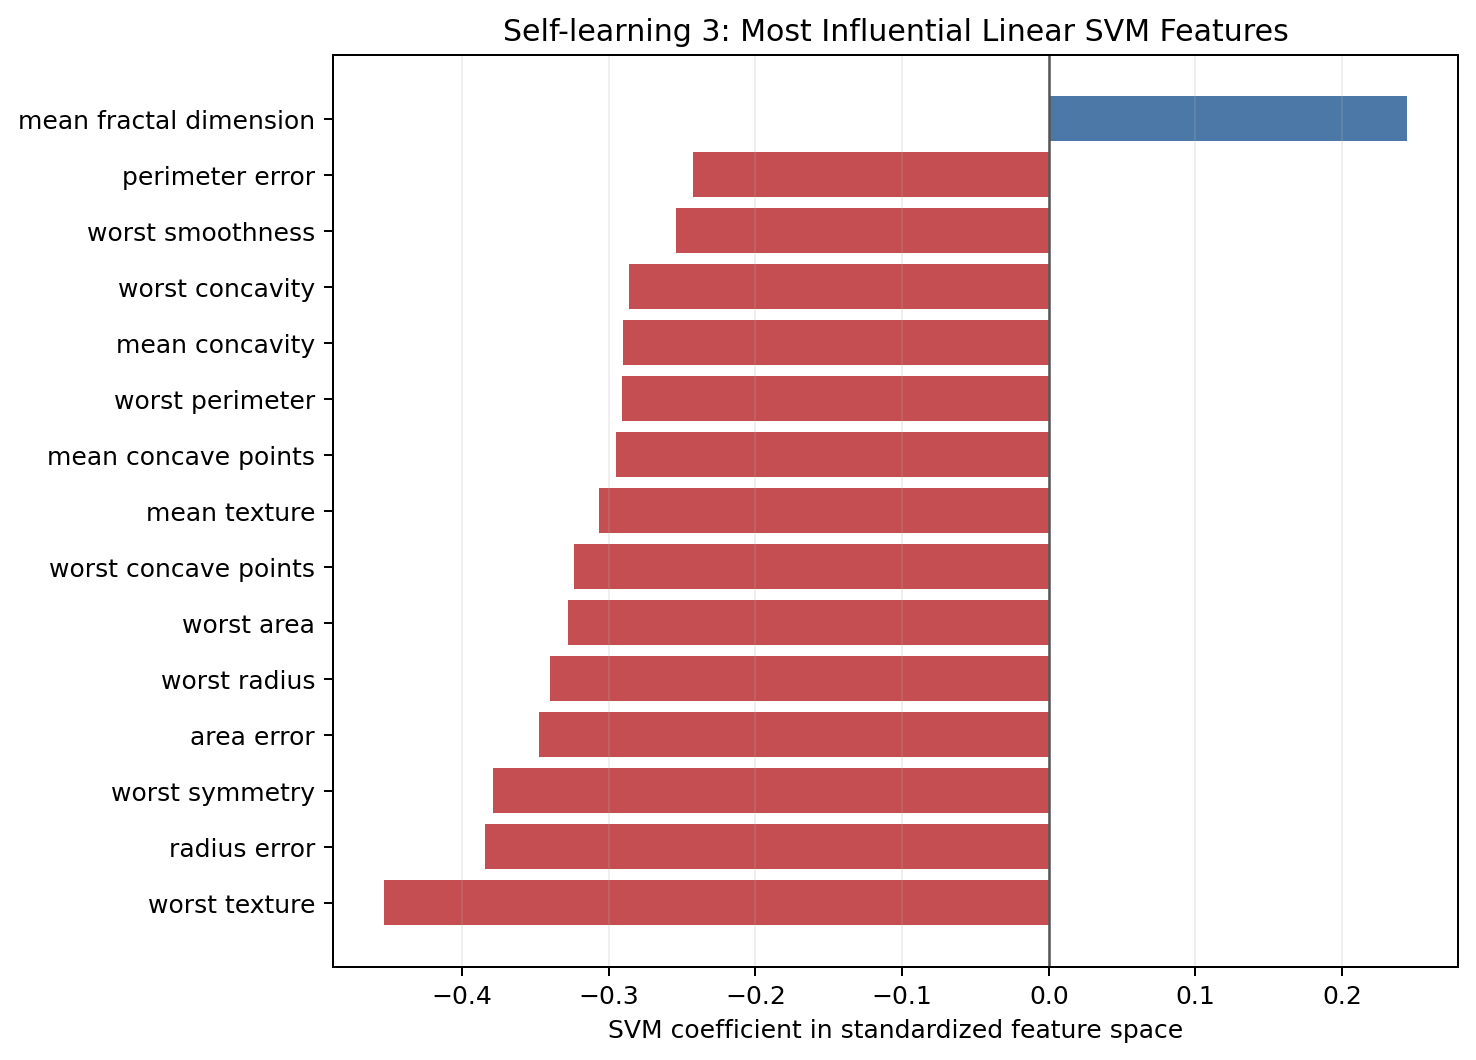

In [ ]:
linear_coefficients = pd.Series(
    linear_search.best_estimator_.named_steps['svm'].coef_[0], index=X_cancer.columns
)
top_coefficients = linear_coefficients.loc[
    linear_coefficients.abs().nlargest(15).index
].sort_values()

fig, ax = plt.subplots(figsize=(8.5, 6))
coefficient_colors = np.where(top_coefficients >= 0, 'steelblue', 'indianred')
ax.barh(top_coefficients.index, top_coefficients.values, color=coefficient_colors)
ax.axvline(0, color='gray', linewidth=1)
ax.set(xlabel='Coefficient in standardized feature space',
       title='Most Influential Linear SVM Features')
ax.grid(axis='x', alpha=0.2); plt.tight_layout(); plt.show()
display(top_coefficients.sort_values(key=np.abs, ascending=False).to_frame('coefficient'))



**Result and interpretation:** `worst texture`, `radius error`, `worst symmetry`, `area error`, and several worst-size or concavity measurements have the largest absolute coefficients. Most of these leading coefficients are negative, meaning larger standardized values push this fitted model toward the malignant class. Correlated predictors can divide or exchange coefficient weight, so the ranking should not be treated as a biological causal ordering.


### Self-learning component 4 — How can PCA samples and feature loadings be read together?

A biplot overlays feature-loading arrows on the PCA sample scatter. Points lying farther in an arrow's direction tend to have larger values for that feature. Similar arrow directions suggest positive correlation; opposing directions suggest negative correlation. To preserve readability, only the eight features with the largest combined PC1–PC2 loading magnitudes are labelled.


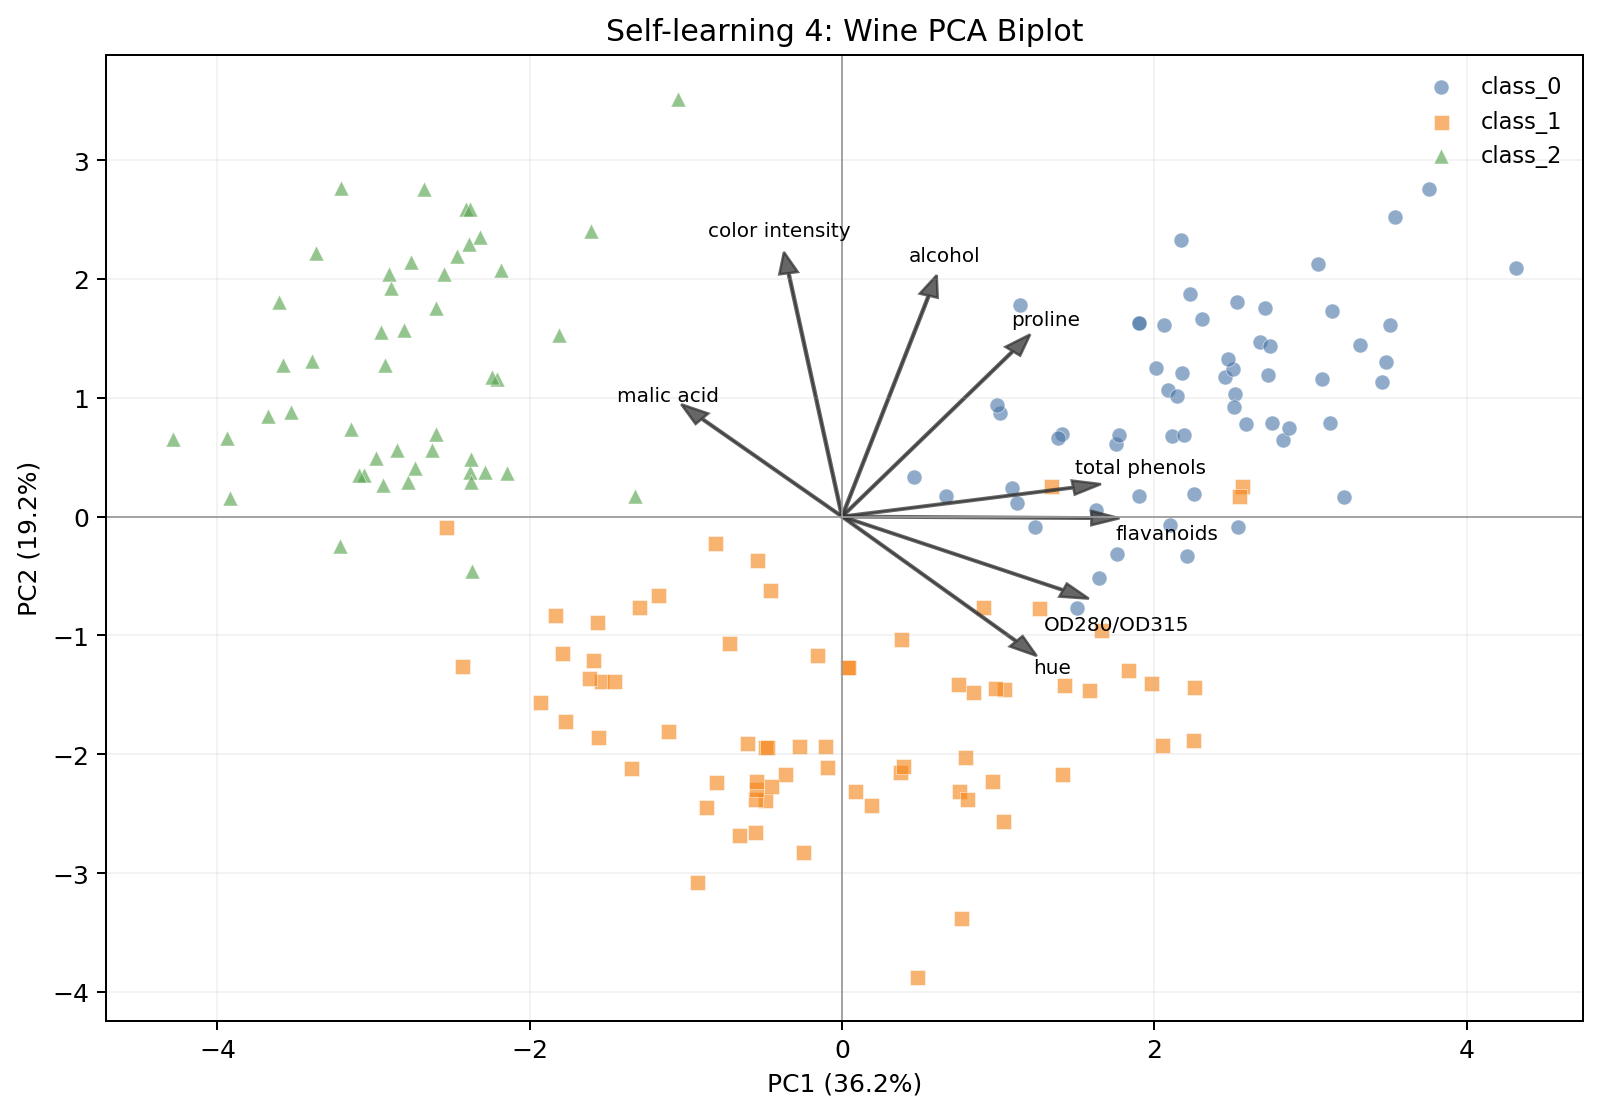

In [ ]:
loading_strength = np.linalg.norm(pca_2d.components_.T, axis=1)
largest_loading_indices = np.argsort(loading_strength)[-8:]
fig, ax = plt.subplots(figsize=(9, 6.5))
markers = ['o', 's', '^']
for class_id, (class_name, marker) in enumerate(zip(wine.target_names, markers)):
    mask = y_wine.to_numpy() == class_id
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], label=class_name,
               marker=marker, alpha=0.62, edgecolors='white', linewidths=0.3)

arrow_scale = 4.2
short_names = {
    'color_intensity': 'color intensity', 'malic_acid': 'malic acid',
    'total_phenols': 'total phenols',
    'od280/od315_of_diluted_wines': 'OD280/OD315'
}
label_offsets = {
    'total_phenols': (0.12, 0.12), 'flavanoids': (0.16, -0.13),
    'od280/od315_of_diluted_wines': (0.05, -0.16)
}
for feature_index in largest_loading_indices:
    x_loading, y_loading = pca_2d.components_[:, feature_index] * arrow_scale
    ax.arrow(0, 0, x_loading, y_loading, color='black', alpha=0.7,
             width=0.012, head_width=0.12, length_includes_head=True)
    feature_name = X_wine.columns[feature_index]
    dx, dy = label_offsets.get(feature_name, (0, 0))
    ax.text(x_loading*1.08+dx, y_loading*1.08+dy,
            short_names.get(feature_name, feature_name),
            fontsize=8, ha='center', va='center')
ax.axhline(0, color='gray', linewidth=0.7); ax.axvline(0, color='gray', linewidth=0.7)
ax.set(xlabel=f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})',
       ylabel=f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})',
       title='Wine PCA Biplot')
ax.legend(frameon=False); ax.grid(alpha=0.15); plt.tight_layout(); plt.show()



**Result and interpretation:** The phenolic measurements point strongly along PC1 and help explain the horizontal cultivar separation. Alcohol, color intensity, and proline contribute strongly to PC2 as well as PC1. The biplot links the abstract component axes back to the original chemistry and makes correlations among features visually apparent.


### Self-learning component 5 — Does retaining more variance always improve classification?

This experiment places standardization, PCA, and a linear SVM inside a cross-validation pipeline and varies the number of PCA components from 1 to 13. It compares the result with all original standardized features and with a two-dimensional LDA projection. Fitting the transformation inside each fold prevents validation-data leakage.


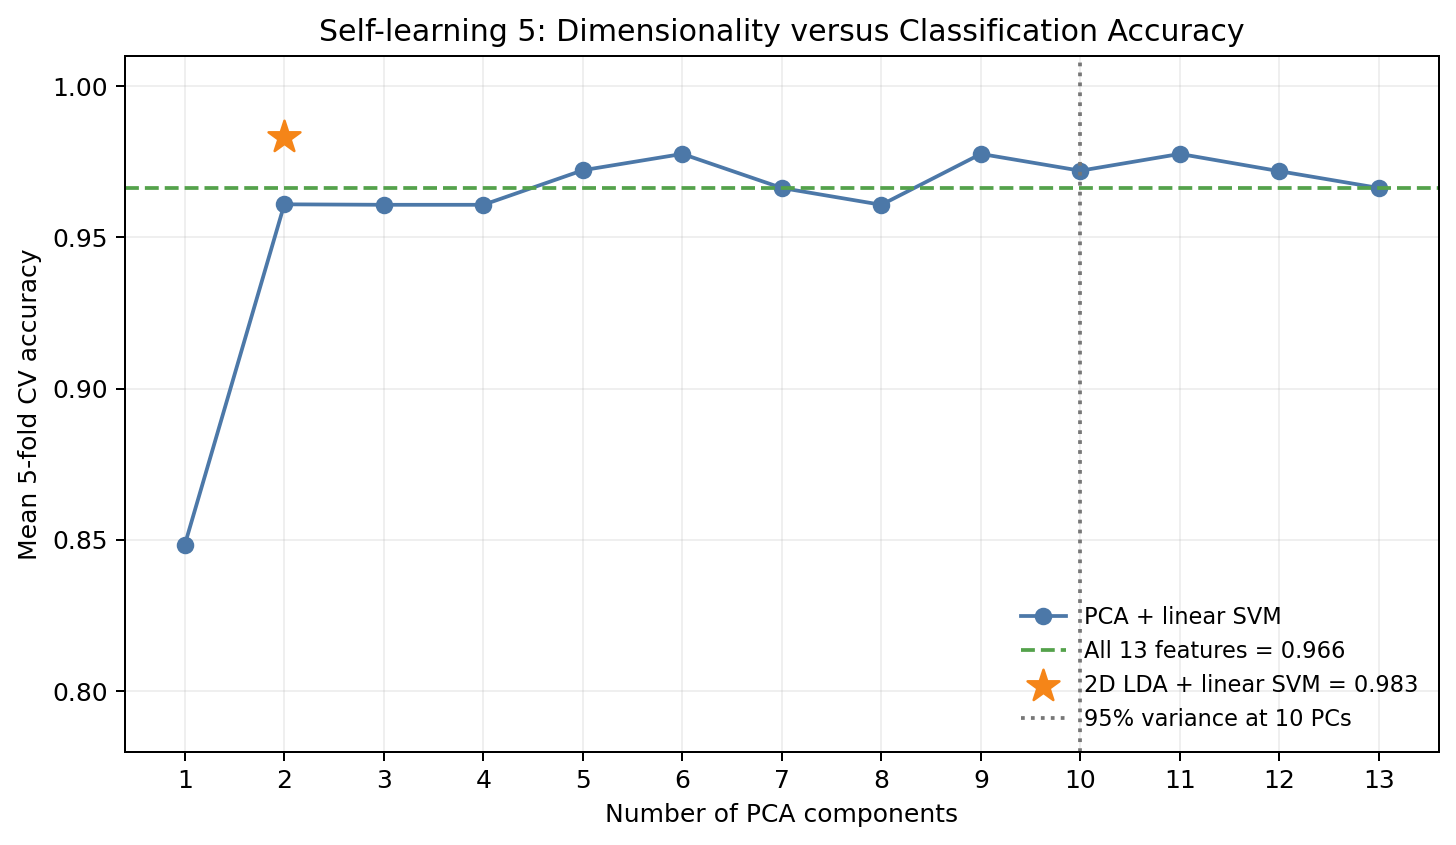

In [ ]:
wine_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
component_counts = np.arange(1, X_wine.shape[1] + 1)
pca_cv_accuracy = []

for component_count in component_counts:
    pca_classifier = Pipeline([
        ('scaler', StandardScaler()),
        ('reduce', PCA(n_components=int(component_count))),
        ('svm', SVC(kernel='linear', C=1))
    ])
    score = cross_val_score(pca_classifier, X_wine, y_wine,
                            cv=wine_cv, scoring='accuracy', n_jobs=1).mean()
    pca_cv_accuracy.append(score)

full_feature_classifier = Pipeline([
    ('scaler', StandardScaler()), ('svm', SVC(kernel='linear', C=1))
])
full_feature_accuracy = cross_val_score(
    full_feature_classifier, X_wine, y_wine, cv=wine_cv, scoring='accuracy', n_jobs=1
).mean()

lda_classifier = Pipeline([
    ('scaler', StandardScaler()),
    ('reduce', LinearDiscriminantAnalysis(n_components=2)),
    ('svm', SVC(kernel='linear', C=1))
])
lda_2d_accuracy = cross_val_score(
    lda_classifier, X_wine, y_wine, cv=wine_cv, scoring='accuracy', n_jobs=1
).mean()

fig, ax = plt.subplots(figsize=(8.5, 4.9))
ax.plot(component_counts, pca_cv_accuracy, marker='o', label='PCA + linear SVM')
ax.axhline(full_feature_accuracy, linestyle='--', color='seagreen',
           label=f'All 13 features = {full_feature_accuracy:.3f}')
ax.scatter([2], [lda_2d_accuracy], marker='*', s=180, color='darkorange', zorder=5,
           label=f'2D LDA + linear SVM = {lda_2d_accuracy:.3f}')
ax.axvline(10, linestyle=':', color='gray', label='95% variance at 10 PCs')
ax.set(xlabel='Number of PCA components', ylabel='Mean 5-fold CV accuracy',
       title='Dimensionality versus Wine Classification Accuracy',
       xticks=component_counts, ylim=(0.78, 1.01))
ax.grid(alpha=0.2); ax.legend(frameon=False, loc='lower right')
plt.tight_layout(); plt.show()

best_index = int(np.argmax(pca_cv_accuracy))
print(f'Best PCA count: {component_counts[best_index]}')
print(f'Best PCA CV accuracy: {pca_cv_accuracy[best_index]:.4f}')
print(f'All-feature CV accuracy: {full_feature_accuracy:.4f}')
print(f'2D LDA CV accuracy: {lda_2d_accuracy:.4f}')



**Result and interpretation:** One PC gives **0.8484** mean accuracy, while two PCs already give **0.9610**. The best observed PCA accuracy is **0.9776**, reached with 6, 9, or 11 components. All 13 original standardized features give **0.9663**, and two-dimensional LDA gives **0.9833**. Classification accuracy is therefore not monotonic in retained variance: lower-variance directions may add noise, and supervised LDA can preserve discriminative information more efficiently. These small differences should be confirmed on larger data or repeated cross-validation.

## Final learning summary

The additional visualizations reveal behavior that the original metrics alone cannot show: regularization controls overfitting; different thresholds trade false positives against false negatives; learning curves diagnose whether more data may help; linear coefficients connect predictions to standardized measurements; biplots connect PCA directions to chemistry; and predictive accuracy does not necessarily increase whenever more variance is retained.
